Dataset Columns:
Index(['User_ID', 'Device_Model', 'Operating_System', 'App_Usage_Time_min_day',
       'Screen_On_Time_hours_day', 'Battery_Drain_mAh_day',
       'Number_of_Apps_Installed', 'Data_Usage_MB_day', 'Age', 'Gender',
       'User_Behavior_Class'],
      dtype='object')

First 5 Rows:
   User_ID    Device_Model Operating_System  App_Usage_Time_min_day  \
0        1  Google Pixel 5          Android                     393   
1        2       OnePlus 9          Android                     268   
2        3    Xiaomi Mi 11          Android                     154   
3        4  Google Pixel 5          Android                     239   
4        5       iPhone 12              iOS                     187   

   Screen_On_Time_hours_day  Battery_Drain_mAh_day  Number_of_Apps_Installed  \
0                       6.4                   1872                        67   
1                       4.7                   1331                        42   
2                       4.0        

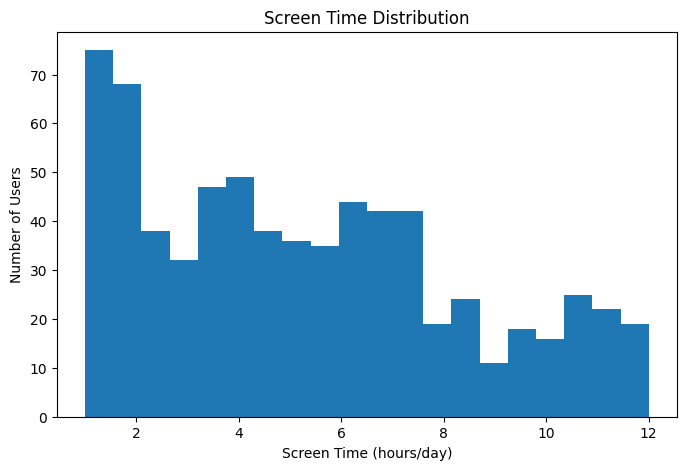

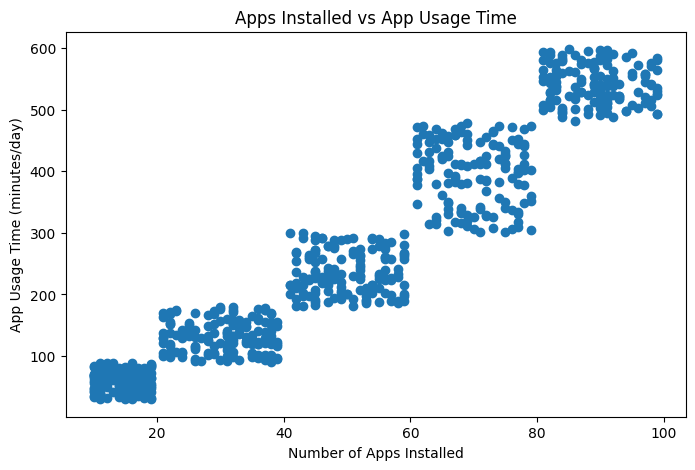

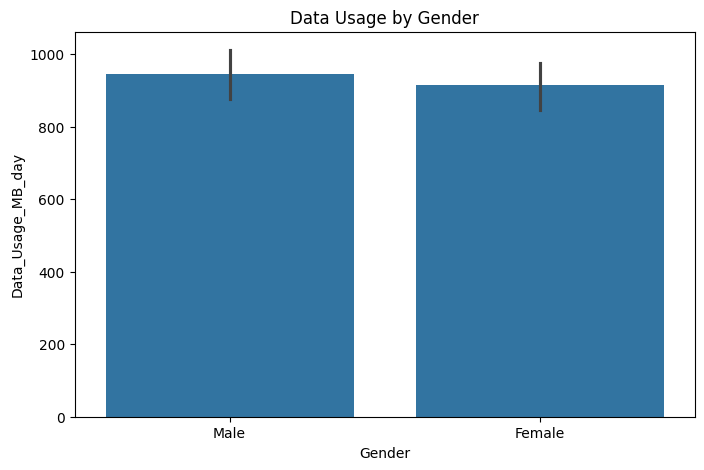

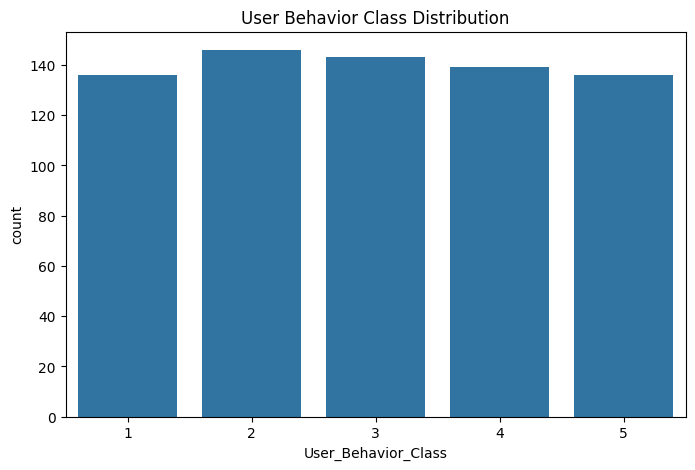

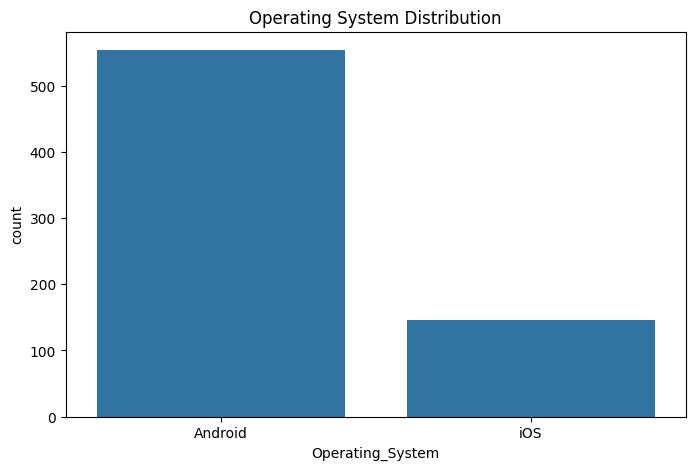

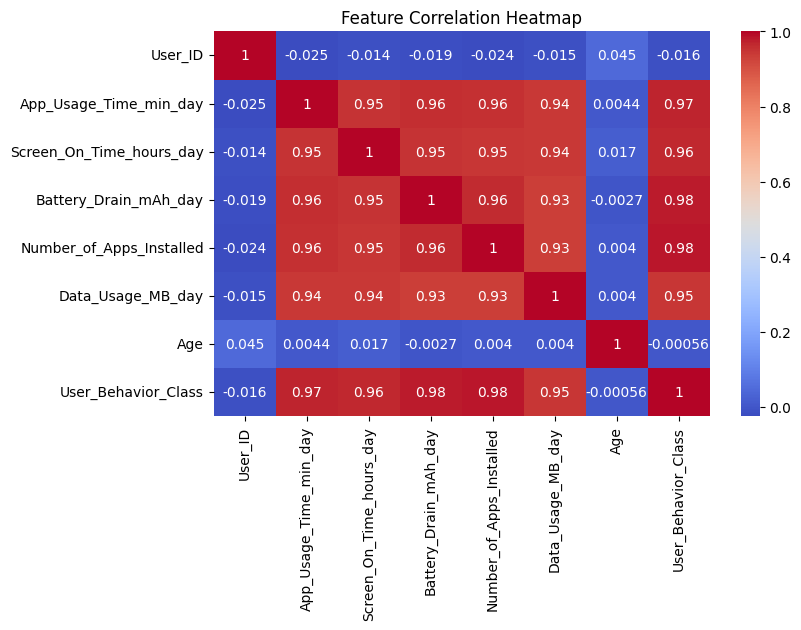


Key Insights:
1. Users with more installed apps tend to spend more time on their phones.
2. Screen time varies across different user behavior classes.
3. Data usage patterns differ between male and female users.
4. Android and iOS users show different usage distributions.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("user_behavior_dataset.csv")

# ----------------------------
# Clean Column Names
# ----------------------------
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)
df.columns = df.columns.str.replace("/", "_")

# Display dataset info
print("Dataset Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# ----------------------------
# Check Missing Values
# ----------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# ----------------------------
# Basic Statistics
# ----------------------------
print("\nDataset Description:")
print(df.describe())

# ----------------------------
# Visualization 1
# Screen Time Distribution
# ----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["Screen_On_Time_hours_day"], bins=20)
plt.title("Screen Time Distribution")
plt.xlabel("Screen Time (hours/day)")
plt.ylabel("Number of Users")
plt.show()

# ----------------------------
# Visualization 2
# Apps Installed vs App Usage
# ----------------------------
plt.figure(figsize=(8,5))
plt.scatter(df["Number_of_Apps_Installed"], df["App_Usage_Time_min_day"])
plt.title("Apps Installed vs App Usage Time")
plt.xlabel("Number of Apps Installed")
plt.ylabel("App Usage Time (minutes/day)")
plt.show()

# ----------------------------
# Visualization 3
# Data Usage by Gender
# ----------------------------
plt.figure(figsize=(8,5))
sns.barplot(x="Gender", y="Data_Usage_MB_day", data=df)
plt.title("Data Usage by Gender")
plt.show()

# ----------------------------
# Visualization 4
# User Behavior Distribution
# ----------------------------
plt.figure(figsize=(8,5))
sns.countplot(x="User_Behavior_Class", data=df)
plt.title("User Behavior Class Distribution")
plt.show()

# ----------------------------
# Visualization 5
# Operating System Usage
# ----------------------------
plt.figure(figsize=(8,5))
sns.countplot(x="Operating_System", data=df)
plt.title("Operating System Distribution")
plt.show()

# ----------------------------
# Correlation Heatmap
# ----------------------------
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ----------------------------
# Insights
# ----------------------------
print("\nKey Insights:")
print("1. Users with more installed apps tend to spend more time on their phones.")
print("2. Screen time varies across different user behavior classes.")
print("3. Data usage patterns differ between male and female users.")
print("4. Android and iOS users show different usage distributions.")